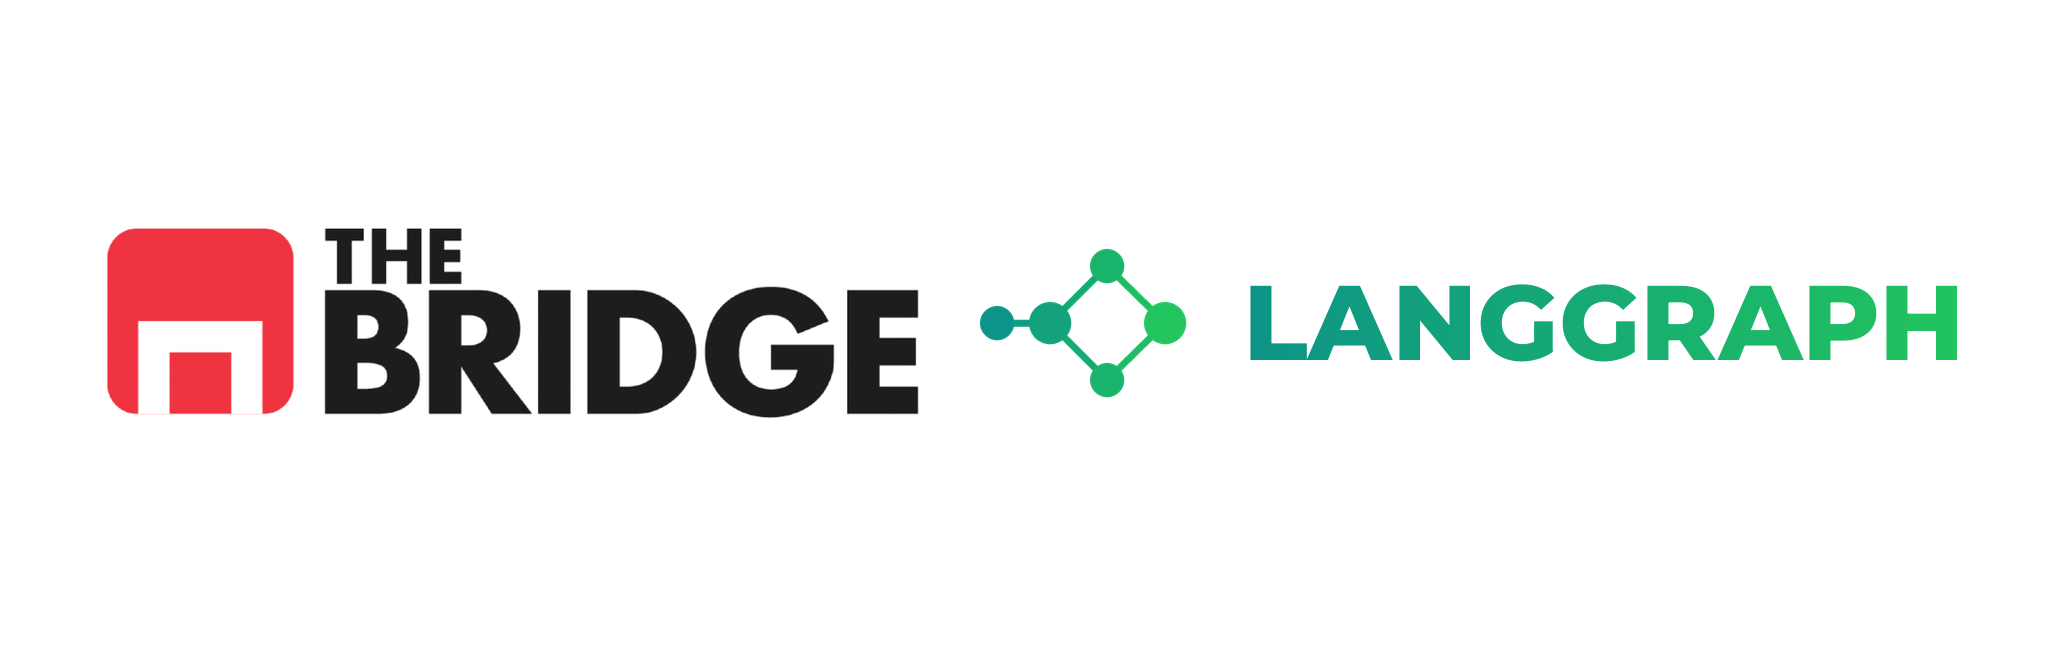

# Workout — Multimodal: imagen → texto con LangGraph

## Objetivo

Ver cómo funciona multimodal **dentro de un grafo**: un nodo lee imagen + pregunta y escribe texto en el **estado**.
Así encaja con el resto del sprint (el agente final también va con LangGraph).

1. Una imagen de cartel en `assets/`.
2. Estado simple: ruta, pregunta, respuesta.
3. Un nodo `leer_imagen` llama a Gemini con **varias parts** (imagen + texto).
4. Grafo lineal: `START → leer_imagen → END`.

```text
START → leer_imagen → END
            │
            ▼
   [ Part imagen ] + [ Part texto ] → Gemini → State.respuesta
```

Dominio: leer un **cartel** (hora / lugar).

## Índice

1. Setup
2. Cargar la imagen
3. Estado compartido
4. Nodo multimodal + grafo
5. Ejecutar el pipeline
6. Para llevarnos

**Requisito:** `GEMINI_API_KEY`

## 1. Setup

LangGraph orquesta el flujo. El SDK `google-genai` hace la llamada multimodal (imagen + texto) **dentro del nodo**.

Descomenta la celda de `%pip` solo la primera vez o si falta algún paquete.

In [ ]:
# %pip install -qU langgraph google-genai python-dotenv

In [1]:
import os
from getpass import getpass

from dotenv import load_dotenv

load_dotenv()

if not os.getenv("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass("Pega tu GEMINI_API_KEY: ")

API_KEY = os.environ["GEMINI_API_KEY"]
print("GEMINI_API_KEY:", "sí" if API_KEY else "no")

GEMINI_API_KEY: sí


## 2. Cargar la imagen

La imagen vive en `assets/cartel_demo.jpg`.

In [ ]:
from pathlib import Path

from IPython.display import Image, display

# Añade aquí tu cartel (PNG o JPG)
IMG_PATH = Path("assets/cartel_demo.jpg")

if not IMG_PATH.exists():
    raise FileNotFoundError(
        f"No está {IMG_PATH.resolve()}. Añade el cartel en assets/."
    )

display(Image(filename=str(IMG_PATH)))

## 3. Estado compartido

El estado es el **canal** del grafo (igual que en multiagente/HITL).
Aquí solo tres campos:

| Campo | Rol |
|-------|-----|
| `ruta_imagen` | Path del PNG/JPG |
| `pregunta` | Instrucción en texto |
| `respuesta` | Texto que escribe el nodo multimodal |

In [3]:
from typing import TypedDict


class EstadoVision(TypedDict):
    ruta_imagen: str
    pregunta: str
    respuesta: str


print("EstadoVision definido")

EstadoVision definido


## 4. Nodo multimodal + grafo

### Contrato multimodal (dentro del nodo)

| Parte | Qué es |
|-------|--------|
| `Part.from_bytes(...)` | La imagen (bytes + `mime_type`) |
| `Part.from_text(...)` | La pregunta del State |

El nodo `leer_imagen`:
1. Lee `ruta_imagen` y `pregunta` del estado.
2. Llama a Gemini con las dos parts.
3. Escribe `respuesta` en el estado.

Grafo **lineal** (sin bucle ni supervisor) para entender cómo encaja multimodal en LangGraph.

In [4]:
from pathlib import Path

from google import genai
from google.genai import types
from langgraph.graph import END, START, StateGraph

client = genai.Client(api_key=API_KEY)


def nodo_leer_imagen(estado: EstadoVision) -> dict:
    """Imagen + pregunta → texto en el State."""
    ruta = Path(estado["ruta_imagen"])
    data = ruta.read_bytes()
    mime = "image/png" if ruta.suffix.lower() == ".png" else "image/jpeg"

    out = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            types.Content(
                role="user",
                parts=[
                    types.Part.from_bytes(data=data, mime_type=mime),
                    types.Part.from_text(text=estado["pregunta"]),
                ],
            )
        ],
    )
    return {"respuesta": (out.text or "").strip()}


grafo = StateGraph(EstadoVision)
grafo.add_node("leer_imagen", nodo_leer_imagen)
grafo.add_edge(START, "leer_imagen")
grafo.add_edge("leer_imagen", END)

app = grafo.compile()
print("Grafo multimodal listo")
print(app.get_graph().draw_ascii())

Grafo multimodal listo
 +-----------+   
 | __start__ |   
 +-----------+   
        *        
        *        
        *        
+-------------+  
| leer_imagen |  
+-------------+  
        *        
        *        
        *        
  +---------+    
  | __end__ |    
  +---------+    


## 5. Ejecutar el pipeline

`invoke` recibe el estado inicial. Al terminar, `respuesta` tiene el texto que Gemini sacó del cartel.

En un agente más grande, ese texto podría alimentar otro nodo o una tool; aquí paramos en `END`.

In [5]:
estado_inicial: EstadoVision = {
    "ruta_imagen": str(IMG_PATH.resolve()),
    "pregunta": (
        "Describe el cartel en 2 frases en español. "
        "Si hay hora o lugar, menciónalos."
    ),
    "respuesta": "",
}

resultado = app.invoke(estado_inicial)

print("=== RESPUESTA (State) ===")
print(resultado.get("respuesta") or "(vacía)")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


=== RESPUESTA (State) ===
Este cartel es una entrada para un concierto de la banda Queen que tuvo lugar el martes 5 de agosto en Marbella. El evento se celebró en el Estadio de Football, con apertura de puertas a las 20:00 horas y el concierto comenzando a las 23:00 horas.


## 6. Para llevarnos

| Pieza | Rol |
|-------|-----|
| `EstadoVision` | Canal del grafo (`ruta`, `pregunta`, `respuesta`) |
| `nodo_leer_imagen` | Llama a Gemini multimodal y escribe en el State |
| `Part.from_bytes` / `Part.from_text` | Contrato multimodal dentro del nodo |
| Grafo lineal | `START → leer_imagen → END` |

En este workout has visto multimodal **encajado en LangGraph**: la visión no es un chat aparte; es un **nodo** que convierte imagen → texto y lo deja en el estado.

En un agente mayor (ReAct, supervisor, HITL) el patrón es el mismo: un nodo o una tool hace la llamada multimodal y el resto del grafo sigue trabajando con texto.

**Idea clave:** multimodal = **parts en el mensaje**; LangGraph = **dónde** vive ese paso en el flujo.
